# 07. 스트리밍 단계별 출력

> 에이전트의 **단계별 진행 상황**이 보여야 사용자가 기다릴 수 있어요. `values` / `updates` / `messages` 세 가지 스트리밍 모드와 서브그래프 추적까지 다룹니다.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. `stream_mode`의 세 가지 모드(`values`, `updates`, `messages`)를 이해하고 차이를 설명할 수 있어요
2. 동기(`graph.stream()`)와 비동기(`graph.astream()`) 스트리밍을 각각 구현할 수 있어요
3. `metadata`를 활용해 특정 노드의 출력만 필터링할 수 있어요
4. `astream_events()`와 태그 기반 필터링으로 세밀한 스트리밍 제어를 할 수 있어요
5. 서브그래프(`subgraphs=True`)의 내부 실행 과정까지 스트리밍으로 추적할 수 있어요

## 사전 지식

- Part 04의 02-Subgraphs: 서브그래프 작성 방법
- Part 02의 04-StateGraph-Basics: StateGraph, 노드, 엣지 구성
- Part 02의 06-Tools-Integration: ToolNode, tools_condition 사용법

## 스트리밍이란?

### 왜 스트리밍이 필요한가요?

ChatGPT를 사용해본 적 있다면, 응답이 한 글자씩 타이핑되듯 나타나는 것을 본 적이 있을 거예요. 이것이 바로 스트리밍이에요. 만약 전체 응답이 완성될 때까지 기다려야 한다면, 긴 답변은 수십 초간 빈 화면만 보게 되죠.

LangGraph의 **스트리밍(Streaming)**은 그래프가 실행되는 동안 중간 결과를 실시간으로 받아볼 수 있는 기능이에요. 이를 통해 사용자 경험이 크게 향상되고, 복잡한 멀티 노드 그래프에서도 진행 상황을 실시간으로 모니터링할 수 있어요.

### 스트리밍 모드 비교

| 모드 | 반환 단위 | 주요 용도 | 비유 |
|------|-----------|----------|------|
| `values` | 노드 실행 후 **전체 State** | 상태 변화 전체 추적, 디버깅 | 매 단계마다 사진을 찍어 앨범에 저장 |
| `updates` | 노드 실행 후 **변경된 부분만** | 노드별 기여분 파악, 효율적 처리 | 매 단계마다 "뭐가 바뀌었는지"만 메모 |
| `messages` | **토큰 단위** LLM 출력 | 실시간 응답 표시, 사용자 UX 향상 | ChatGPT처럼 한 글자씩 타이핑 |

> 🔑 **핵심 개념**: `stream_mode`는 **무엇을** 스트리밍할지 결정해요. `values`는 누적 전체 상태, `updates`는 변경분, `messages`는 LLM 토큰 단위 출력이에요.

## 전체 아키텍처

```mermaid
flowchart LR
    입력["사용자 입력<br>User Input"] --> 그래프["LangGraph<br>그래프"]
    
    그래프 --> values_mode["values 모드<br>전체 State 반환"]
    그래프 --> updates_mode["updates 모드<br>변경분만 반환"]
    그래프 --> messages_mode["messages 모드<br>토큰 단위 스트리밍"]
    
    messages_mode --> 필터링["노드 필터링<br>metadata['langgraph_node']"]
    messages_mode --> 태그필터링["태그 필터링<br>astream_events()"]
    
    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef storage fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
    
    class 입력 input
    class 그래프 process
    class values_mode,updates_mode,messages_mode output
    class 필터링,태그필터링 storage
```

### 동기 vs 비동기 스트리밍

| 방식 | 메서드 | 반복문 | 적합한 환경 |
|------|--------|--------|-------------|
| 동기 | `graph.stream()` | `for chunk in ...` | 스크립트, 간단한 실험 |
| 비동기 | `graph.astream()` | `async for chunk in ...` | 서버, API, 동시 요청 처리 |

> 💡 **실무 팁**: 주피터 노트북은 기본적으로 비동기 실행이 가능해요. `async for`를 그냥 셀에서 사용할 수 있어요. 실제 프로덕션 서버(FastAPI, aiohttp 등)에서는 비동기 방식이 성능상 훨씬 유리해요.

## 환경 설정

In [1]:
# 환경 변수 로드 (.env 파일에서 API 키 등을 읽어요)
from dotenv import load_dotenv
import os

load_dotenv()

# LangSmith 추적 설정 (그래프 실행 과정을 모니터링해요)
# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-V1-Tutorial-Part04-07"

True

## 에이전트 그래프 정의

스트리밍 실습을 위한 도구 검색 에이전트를 만들어볼게요. 이 에이전트는 키워드 뉴스 검색 도구를 사용하고, 결과를 요약해서 답변해요.

> 🎯 **강의 포인트**: 이 그래프 구조(`chatbot → tools → chatbot → END`)는 Part 02의 06-Tools-Integration에서 배운 기본 패턴이에요. 스트리밍을 위한 특별한 수정 없이 그대로 사용해요.

In [2]:
# ---------------------------------------------------
# 스트리밍 실습용 뉴스 검색 에이전트 정의
# ---------------------------------------------------
from typing import Annotated, List, Dict
from typing_extensions import TypedDict
from langchain.tools import tool
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition


# 1. 상태(State) 정의: 메시지 리스트를 누적해요
class State(TypedDict):
    messages: Annotated[list, add_messages]  # add_messages: 메시지를 덮어쓰지 않고 누적


# 2. 도구 정의: 키워드로 최신 뉴스를 검색해요
@tool
def search_news(query: str) -> str:
    """키워드로 최신 뉴스를 검색합니다."""
    # 실습용 더미 뉴스 데이터 (실제 환경에서는 GoogleNews 등으로 대체)
    dummy_news = {
        "AI": [
            "현대차그룹, 피지컬 AI 로봇에 125조원 투자 발표 - 지디넷코리아",
            "삼성전자, 갤럭시 S26에 퍼플렉시티 AI 에이전트 기본 탑재 - AI타임스",
            "네이버·카카오, AI 기업으로 전환 가속화 - 한국경제",
            "한국, AI 개발 시 오픈소스 활용률 세계 1위 - 조선일보",
            "LG전자, 가전 AI 에이전트 '스마트홈 AI' 출시 - 연합뉴스",
        ],
        "반도체": [
            "삼성전자 HBM4 양산 일정 앞당겨... NVIDIA 공급 확대 - 매일경제",
            "SK하이닉스, AI 반도체 수요 급증으로 분기 최대 실적 - 연합뉴스",
            "인텔, 차세대 AI 가속기 칩 개발 완료 발표 - 한국경제",
        ],
    }
    # 쿼리와 관련된 뉴스를 찾아요 (대소문자 무시)
    for key, articles in dummy_news.items():
        if key.lower() in query.lower() or query.lower() in key.lower():
            return "\n".join([f"- {a}" for a in articles])
    # 관련 뉴스가 없을 때 기본 반환
    return f"'{query}' 관련 최신 뉴스:\n- 검색 결과가 없습니다. 다른 키워드를 시도해보세요."


# 3. LLM 초기화: gpt-4o-mini 사용 (비용 효율적)
# - Anthropic Claude: "anthropic:claude-sonnet-4-5"
# - Google Gemini: "google_genai:gemini-2.0-flash"
llm = init_chat_model("openai:gpt-4o-mini")

# 도구를 LLM에 바인딩해요
tools = [search_news]
llm_with_tools = llm.bind_tools(tools)


# 4. 노드 함수 정의
def chatbot(state: State) -> dict:
    """LLM이 메시지를 처리하고 응답(또는 도구 호출)을 생성해요."""
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


# 5. 그래프 구성
graph_builder = StateGraph(State)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

# 조건부 엣지: chatbot이 도구 호출 시 tools로, 아니면 END로
graph_builder.add_conditional_edges("chatbot", tools_condition)
graph_builder.add_edge("tools", "chatbot")  # 도구 실행 후 다시 chatbot으로
graph_builder.add_edge(START, "chatbot")

# 그래프 컴파일
graph = graph_builder.compile()

# 그래프 정의 완료!

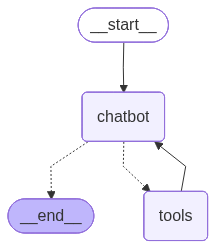

In [3]:
# 그래프 흐름: START → chatbot → {tools_condition} → tools 또는 END
# chatbot 노드: LLM이 메시지를 처리하고 응답 또는 도구 호출을 생성해요
# 조건부 엣지: tool_calls가 있으면 tools로, 없으면 END로 분기해요
# tools 노드: 도구 실행 후 다시 chatbot으로 돌아가요 (에이전트 루프)
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

## 1. stream_mode="values" — 전체 상태 스트리밍

`values` 모드는 각 노드가 실행될 때마다 **그래프의 전체 State**를 반환해요.

- 반환 형태: `{state_key: state_value, ...}` (딕셔너리)
- 특징: 누적된 전체 상태를 볼 수 있어서, 이전 노드의 결과도 포함해요
- 적합한 상황: 상태 변화를 전체적으로 추적하고 싶을 때, 디버깅

> ⚠️ **자주 하는 실수**: `values` 모드에서 `chunk`는 **전체 상태**예요. 따라서 `chunk["messages"]`의 마지막 원소만 새로 추가된 메시지예요. 전체를 출력하면 이전 메시지들이 중복 출력돼요.

### 1-1. 동기(Synchronous) 방식 — values

In [4]:
# ---------------------------------------------------
# stream_mode="values" 동기 스트리밍
# ---------------------------------------------------
# 입력: 사용자 메시지
inputs = {"messages": [("human", "AI 관련 최신 뉴스를 검색해줘")]}

# ============================================================
# [동기 스트리밍 - values 모드]
# ============================================================

# graph.stream(): 동기 스트림 반환
# chunk: {state_key: state_value, ...} 형태의 딕셔너리
for chunk in graph.stream(inputs, stream_mode="values"):
    # State의 각 키-값을 순회해요
    for state_key, state_value in chunk.items():
        if state_key == "messages":
            # 마지막 메시지만 출력해요 (새로 추가된 메시지)
            print(f"\n[새 메시지]:")
            state_value[-1].pretty_print()


[새 메시지]:
================================ Human Message =================================

AI 관련 최신 뉴스를 검색해줘

[새 메시지]:
================================== Ai Message ==================================
Tool Calls:
  search_news (call_xJVkNMedfrOd3wcx5uGv96nL)
 Call ID: call_xJVkNMedfrOd3wcx5uGv96nL
  Args:
    query: AI

[새 메시지]:
================================= Tool Message =================================
Name: search_news

- 현대차그룹, 피지컬 AI 로봇에 125조원 투자 발표 - 지디넷코리아
- 삼성전자, 갤럭시 S26에 퍼플렉시티 AI 에이전트 기본 탑재 - AI타임스
- 네이버·카카오, AI 기업으로 전환 가속화 - 한국경제
- 한국, AI 개발 시 오픈소스 활용률 세계 1위 - 조선일보
- LG전자, 가전 AI 에이전트 '스마트홈 AI' 출시 - 연합뉴스

[새 메시지]:
================================== Ai Message ==================================

최신 AI 관련 뉴스는 다음과 같습니다:

1. **현대차그룹, 피지컬 AI 로봇에 125조원 투자 발표** - 지디넷코리아
2. **삼성전자, 갤럭시 S26에 퍼플렉시티 AI 에이전트 기본 탑재** - AI타임스
3. **네이버·카카오, AI 기업으로 전환 가속화** - 한국경제
4. **한국, AI 개발 시 오픈소스 활용률 세계 1위** - 조선일보
5. **LG전자, 가전 AI 에이전트 '스마트홈 AI' 출시** - 연합뉴스

이러한 뉴스들은 현재 AI 기술의 발전과 기업들의 전략에 대한 관심을 

### 1-2. 비동기(Asynchronous) 방식 — values

In [5]:
# ---------------------------------------------------
# stream_mode="values" 비동기 스트리밍
# ---------------------------------------------------
# 주피터에서는 async for를 바로 사용할 수 있어요
inputs = {"messages": [("human", "AI 관련 최신 뉴스를 검색해줘")]}

# ============================================================
# [비동기 스트리밍 - values 모드]
# ============================================================

# graph.astream(): 비동기 스트림 반환 (async for로 순회)
async for chunk in graph.astream(inputs, stream_mode="values"):
    for state_key, state_value in chunk.items():
        if state_key == "messages":
            print(f"\n[새 메시지]:")
            state_value[-1].pretty_print()


[새 메시지]:
================================ Human Message =================================

AI 관련 최신 뉴스를 검색해줘

[새 메시지]:
================================== Ai Message ==================================
Tool Calls:
  search_news (call_F7x29rtwrCUAMmWf4g3M6yox)
 Call ID: call_F7x29rtwrCUAMmWf4g3M6yox
  Args:
    query: AI

[새 메시지]:
================================= Tool Message =================================
Name: search_news

- 현대차그룹, 피지컬 AI 로봇에 125조원 투자 발표 - 지디넷코리아
- 삼성전자, 갤럭시 S26에 퍼플렉시티 AI 에이전트 기본 탑재 - AI타임스
- 네이버·카카오, AI 기업으로 전환 가속화 - 한국경제
- 한국, AI 개발 시 오픈소스 활용률 세계 1위 - 조선일보
- LG전자, 가전 AI 에이전트 '스마트홈 AI' 출시 - 연합뉴스

[새 메시지]:
================================== Ai Message ==================================

최근 AI 관련 뉴스는 다음과 같습니다:

1. **현대차그룹, 피지컬 AI 로봇에 125조원 투자 발표** - 지디넷코리아
2. **삼성전자, 갤럭시 S26에 퍼플렉시티 AI 에이전트 기본 탑재** - AI타임스
3. **네이버·카카오, AI 기업으로 전환 가속화** - 한국경제
4. **한국, AI 개발 시 오픈소스 활용률 세계 1위** - 조선일보
5. **LG전자, 가전 AI 에이전트 '스마트홈 AI' 출시** - 연합뉴스

더 궁금한 점이나 특정 기사에 대한 추가 정보가 필요하시면 말씀해 주세

### 1-3. 최종 결과만 추출하기

스트리밍하면서도 최종 결과만 필요한 경우가 있어요. 마지막 청크를 `final_result`에 저장하는 패턴을 사용해요.

> 💡 **실무 팁**: 이 패턴은 백엔드에서 스트리밍 처리를 하면서도 최종 응답을 DB에 저장해야 할 때 유용해요. 스트리밍과 최종 결과 저장을 동시에 처리할 수 있어요.

In [6]:
# ---------------------------------------------------
# 최종 결과만 추출하는 패턴
# ---------------------------------------------------
inputs = {"messages": [("human", "AI 관련 최신 뉴스를 검색해줘")]}

final_result = None  # 마지막 청크를 저장할 변수

# 스트리밍하면서 마지막 청크를 계속 갱신해요
async for chunk in graph.astream(inputs, stream_mode="values"):
    final_result = chunk  # 마지막에 할당된 값이 최종 결과

# 스트리밍이 끝난 후 최종 결과 출력
# ============================================================
# [최종 결과 (마지막 State)]
# ============================================================
if final_result:
    final_result["messages"][-1].pretty_print()

================================== Ai Message ==================================

다음은 AI 관련 최신 뉴스입니다:

1. **현대차그룹, 피지컬 AI 로봇에 125조원 투자 발표** - 지디넷코리아
2. **삼성전자, 갤럭시 S26에 퍼플렉시티 AI 에이전트 기본 탑재** - AI타임스
3. **네이버·카카오, AI 기업으로 전환 가속화** - 한국경제
4. **한국, AI 개발 시 오픈소스 활용률 세계 1위** - 조선일보
5. **LG전자, 가전 AI 에이전트 '스마트홈 AI' 출시** - 연합뉴스

더 자세한 정보가 필요하시면 말씀해 주세요!


## 2. stream_mode="updates" — 변경분만 스트리밍

`updates` 모드는 각 노드 실행 후 **변경된 부분만** 반환해요.

- 반환 형태: `{node_name: {state_key: updated_value, ...}, ...}`
- 특징: **어떤 노드가** 무엇을 변경했는지 명확히 파악 가능
- 적합한 상황: 노드별 기여분 분석, 부분적인 상태 업데이트 처리

> 🔑 **핵심 개념**: `updates` 모드의 `chunk`는 `{노드이름: {업데이트내용}}` 형태예요. 전체 State가 아니라 해당 노드가 **반환한 값**만 포함해요. 데이터 전송량이 `values` 모드보다 적어요.

### 2-1. 동기(Synchronous) 방식 — updates

In [7]:
# ---------------------------------------------------
# stream_mode="updates" 동기 스트리밍
# ---------------------------------------------------
inputs = {"messages": [("human", "AI 관련 최신 뉴스를 검색해줘")]}

# ============================================================
# [동기 스트리밍 - updates 모드]
# ============================================================

# chunk: {node_name: {state_key: updated_value}} 형태
for chunk in graph.stream(inputs, stream_mode="updates"):
    # node: 현재 실행된 노드 이름, value: 해당 노드의 출력값
    for node, value in chunk.items():
        print(f"\n[노드: {node}]")
        if "messages" in value:
            value["messages"][-1].pretty_print()
        else:
            print(value)


[노드: chatbot]
================================== Ai Message ==================================
Tool Calls:
  search_news (call_0JQfKNf9DtfkfCnAgSTyvY6W)
 Call ID: call_0JQfKNf9DtfkfCnAgSTyvY6W
  Args:
    query: AI

[노드: tools]
================================= Tool Message =================================
Name: search_news

- 현대차그룹, 피지컬 AI 로봇에 125조원 투자 발표 - 지디넷코리아
- 삼성전자, 갤럭시 S26에 퍼플렉시티 AI 에이전트 기본 탑재 - AI타임스
- 네이버·카카오, AI 기업으로 전환 가속화 - 한국경제
- 한국, AI 개발 시 오픈소스 활용률 세계 1위 - 조선일보
- LG전자, 가전 AI 에이전트 '스마트홈 AI' 출시 - 연합뉴스

[노드: chatbot]
================================== Ai Message ==================================

다음은 AI 관련 최신 뉴스입니다:

1. **현대차그룹, 피지컬 AI 로봇에 125조원 투자 발표** - 지디넷코리아
2. **삼성전자, 갤럭시 S26에 퍼플렉시티 AI 에이전트 기본 탑재** - AI타임스
3. **네이버·카카오, AI 기업으로 전환 가속화** - 한국경제
4. **한국, AI 개발 시 오픈소스 활용률 세계 1위** - 조선일보
5. **LG전자, 가전 AI 에이전트 '스마트홈 AI' 출시** - 연합뉴스

더 궁금한 점이 있으면 말씀해 주세요!


### 2-2. 비동기(Asynchronous) 방식 — updates

In [8]:
# ---------------------------------------------------
# stream_mode="updates" 비동기 스트리밍
# ---------------------------------------------------
inputs = {"messages": [("human", "AI 관련 최신 뉴스를 검색해줘")]}

# ============================================================
# [비동기 스트리밍 - updates 모드]
# ============================================================

async for chunk in graph.astream(inputs, stream_mode="updates"):
    for node, value in chunk.items():
        print(f"\n[노드: {node}]")
        if "messages" in value:
            value["messages"][-1].pretty_print()
        else:
            print(value)


[노드: chatbot]
================================== Ai Message ==================================
Tool Calls:
  search_news (call_fwV5OJfJAuTe8ghBTGXXePZH)
 Call ID: call_fwV5OJfJAuTe8ghBTGXXePZH
  Args:
    query: AI

[노드: tools]
================================= Tool Message =================================
Name: search_news

- 현대차그룹, 피지컬 AI 로봇에 125조원 투자 발표 - 지디넷코리아
- 삼성전자, 갤럭시 S26에 퍼플렉시티 AI 에이전트 기본 탑재 - AI타임스
- 네이버·카카오, AI 기업으로 전환 가속화 - 한국경제
- 한국, AI 개발 시 오픈소스 활용률 세계 1위 - 조선일보
- LG전자, 가전 AI 에이전트 '스마트홈 AI' 출시 - 연합뉴스

[노드: chatbot]
================================== Ai Message ==================================

다음은 AI 관련 최신 뉴스입니다:

1. **현대차그룹, 피지컬 AI 로봇에 125조원 투자 발표** - 지디넷코리아
2. **삼성전자, 갤럭시 S26에 퍼플렉시티 AI 에이전트 기본 탑재** - AI타임스
3. **네이버·카카오, AI 기업으로 전환 가속화** - 한국경제
4. **한국, AI 개발 시 오픈소스 활용률 세계 1위** - 조선일보
5. **LG전자, 가전 AI 에이전트 '스마트홈 AI' 출시** - 연합뉴스

더 궁금한 내용이 있으시면 말씀해 주세요!


## 3. stream_mode="messages" -- 토큰 단위 스트리밍

`messages` 모드는 LLM이 **토큰을 생성할 때마다** 실시간으로 받아볼 수 있어요. ChatGPT에서 글자가 하나씩 나타나는 효과를 구현하는 핵심 모드예요.

- 반환 형태: `(chunk_msg, metadata)` 튜플
  - `chunk_msg`: 실시간 토큰 청크 메시지
  - `metadata`: 노드 정보 딕셔너리 (`langgraph_node`, `langgraph_step`, `langgraph_triggers` 등)
- 적합한 상황: 사용자 인터페이스에서 실시간 응답 표시, 챗봇 UX

### values vs updates vs messages 출력 비교

```
# values 모드 - 전체 State 반환
{"messages": [Human("질문"), AI("답변 전체...")]}

# updates 모드 - 변경분만 반환
{"chatbot": {"messages": [AI("답변 전체...")]}}

# messages 모드 - 토큰 하나씩 반환
("답", metadata)
("변", metadata)
("의", metadata)
(" ", metadata)
("시", metadata)
("작", metadata)
...
```

> 🎯 **강의 포인트**: `metadata["langgraph_node"]`를 확인하면 어떤 노드에서 나온 토큰인지 알 수 있어요. 이걸 이용해서 도구 호출 토큰은 건너뛰고 최종 답변 토큰만 화면에 보여주는 필터링이 가능해요.

### 3-1. 동기(Synchronous) 방식 — messages

In [9]:
# ---------------------------------------------------
# stream_mode="messages" 동기 스트리밍
# ---------------------------------------------------
inputs = {"messages": [("human", "AI 관련 최신 뉴스를 검색해줘")]}

# ============================================================
# [chatbot 노드 토큰 스트리밍]
# ============================================================

# chunk_msg: 실시간 토큰 청크, metadata: 노드 정보
for chunk_msg, metadata in graph.stream(inputs, stream_mode="messages"):
    # chatbot 노드에서 나온 토큰만 출력해요 (도구 노드 토큰 제외)
    if metadata["langgraph_node"] == "chatbot":
        if chunk_msg.content:  # 빈 청크는 건너뛰어요
            print(chunk_msg.content, end="", flush=True)  # flush=True: 즉시 출력

print()  # 마지막 줄바꿈

다음은 AI 관련 최신 뉴스입니다:

1. **현대차그룹, 피지컬 AI 로봇에 125조원 투자 발표** - 지디넷코리아
2. **삼성전자, 갤럭시 S26에 퍼플렉시티 AI 에이전트 기본 탑재** - AI타임스
3. **네이버·카카오, AI 기업으로 전환 가속화** - 한국경제
4. **한국, AI 개발 시 오픈소스 활용률 세계 1위** - 조선일보
5. **LG전자, 가전 AI 에이전트 '스마트홈 AI' 출시** - 연합뉴스

더 자세한 정보가 필요하신가요?


### 3-2. metadata 구조 확인

`metadata` 딕셔너리에는 어떤 정보가 담겨 있는지 확인해볼게요.

> 🔑 **핵심 개념**: `metadata`의 주요 키들
> - `langgraph_node`: 현재 메시지를 생성한 **노드 이름**
> - `langgraph_step`: 그래프 실행의 **단계 번호** (0부터 시작)
> - `langgraph_triggers`: 현재 노드를 **실행시킨 트리거** (이전 노드 이름)
> - `tags`: LLM에 설정된 **태그 목록**

In [10]:
# ---------------------------------------------------
# metadata 구조 분석
# ---------------------------------------------------
inputs = {"messages": [("human", "AI 관련 최신 뉴스를 검색해줘")]}

# 각 노드별 마지막 metadata를 저장해요
node_metadata = {}

for chunk_msg, metadata in graph.stream(inputs, stream_mode="messages"):
    node_name = metadata["langgraph_node"]
    node_metadata[node_name] = metadata  # 노드별 마지막 metadata 저장

# 수집된 metadata 출력
# 각 노드의 metadata 정보:
# ============================================================
for node_name, meta in node_metadata.items():
    print(f"\n[노드: {node_name}]")
    for key, value in meta.items():
        # 주요 키만 출력 (내부 구현 키는 제외)
        if not key.startswith("checkpoint") and not key.startswith("ls_"):
            print(f"  {key}: {value}")


[노드: chatbot]
  langgraph_step: 3
  langgraph_node: chatbot
  langgraph_triggers: ('branch:to:chatbot',)
  langgraph_path: ('__pregel_pull', 'chatbot')
  langgraph_checkpoint_ns: chatbot:07a85cd9-f908-bb19-309e-ed08ba9313c1

[노드: tools]
  langgraph_step: 2
  langgraph_node: tools
  langgraph_triggers: ('branch:to:tools',)
  langgraph_path: ('__pregel_pull', 'tools')
  langgraph_checkpoint_ns: tools:ec1a1c95-723f-c1c1-0e28-9a161a83bc99


### 3-3. 비동기(Asynchronous) 방식 — messages

In [11]:
# ---------------------------------------------------
# stream_mode="messages" 비동기 스트리밍
# ---------------------------------------------------
from langchain.messages import HumanMessage

inputs = {"messages": [("human", "AI 관련 최신 뉴스를 검색해줘")]}

# ============================================================
# [비동기 - chatbot 노드 토큰만 출력]
# ============================================================

# 비동기 스트리밍 - 사용자 메시지와 도구 응답은 제외하고 LLM 응답 토큰만 표시
async for chunk_msg, metadata in graph.astream(inputs, stream_mode="messages"):
    if (
        chunk_msg.content
        and not isinstance(chunk_msg, HumanMessage)  # 사용자 메시지 제외
        and metadata["langgraph_node"] == "chatbot"   # chatbot 노드만 포함
    ):
        print(chunk_msg.content, end="", flush=True)

print()

다음은 AI 관련 최신 뉴스입니다:

1. **현대차그룹, 피지컬 AI 로봇에 125조원 투자 발표** - 지디넷코리아
2. **삼성전자, 갤럭시 S26에 퍼플렉시티 AI 에이전트 기본 탑재** - AI타임스
3. **네이버·카카오, AI 기업으로 전환 가속화** - 한국경제
4. **한국, AI 개발 시 오픈소스 활용률 세계 1위** - 조선일보
5. **LG전자, 가전 AI 에이전트 '스마트홈 AI' 출시** - 연합뉴스

더 궁금한 내용이 있으면 말씀해 주세요!


## 4. 태그 기반 필터링 스트리밍

### 왜 태그가 필요한가요?

복잡한 그래프에서는 여러 LLM이 각각 다른 역할을 해요. 예를 들어 하나는 뉴스를 검색하고, 다른 하나는 SNS 포스트를 만들어요. 사용자에게는 최종 결과만 보여주고 싶은데, 스트리밍하면 모든 LLM의 토큰이 섞여서 나와요. **태그(tag)**를 붙이면 원하는 LLM 출력만 골라서 스트리밍할 수 있어요.

태그를 설정하는 방법:
```python
llm_with_tools = llm.bind_tools(tools).with_config(tags=["MY_STREAM_TAG"])
```

`astream_events()`를 사용하면 이벤트 기반으로 더 세밀하게 제어할 수 있어요.

> 💡 **실무 팁**: 멀티 에이전트 시스템에서 각 에이전트의 LLM에 다른 태그를 부여하면, 원하는 에이전트의 출력만 선택적으로 사용자에게 표시할 수 있어요.

> ⚠️ **자주 하는 실수**: `astream_events()`를 사용할 때 `version="v2"`를 지정하지 않으면 이전 버전의 이벤트 형식이 적용돼요. 항상 `version="v2"`를 명시하세요.

In [12]:
# ---------------------------------------------------
# 태그가 설정된 그래프 재정의
# ---------------------------------------------------

# LLM에 'WANT_TO_STREAM' 태그 추가
# with_config(): 런타임 설정을 추가하는 메서드
llm_with_tools_tagged = llm.bind_tools(tools).with_config(tags=["WANT_TO_STREAM"])


def chatbot_tagged(state: State) -> dict:
    """태그가 적용된 LLM으로 응답을 생성해요."""
    return {"messages": [llm_with_tools_tagged.invoke(state["messages"])]}


# 태그 적용 그래프 구성
tagged_builder = StateGraph(State)
tagged_builder.add_node("chatbot", chatbot_tagged)
tagged_builder.add_node("tools", ToolNode(tools=tools))
tagged_builder.add_conditional_edges("chatbot", tools_condition)
tagged_builder.add_edge("tools", "chatbot")
tagged_builder.add_edge(START, "chatbot")

graph_tagged = tagged_builder.compile()
# 태그 적용 그래프 준비 완료!

In [ ]:
# ---------------------------------------------------
# astream_events()를 활용한 태그 기반 필터링
# ---------------------------------------------------
inputs = {"messages": [("human", "AI 관련 최신 뉴스를 검색해줘")]}

# ============================================================
# [WANT_TO_STREAM 태그 이벤트만 출력]
# ============================================================

# astream_events(): 이벤트 기반 스트리밍 (version="v2" 권장)
async for event in graph_tagged.astream_events(inputs, version="v2"):
    kind = event["event"]      # 이벤트 종류 (on_chat_model_stream 등)
    tags = event.get("tags", [])  # 이 이벤트에 연결된 태그 목록

    # 조건: chat model 스트림 이벤트 AND 원하는 태그가 있을 때만 출력
    if kind == "on_chat_model_stream" and "WANT_TO_STREAM" in tags:
        data = event["data"]
        if data["chunk"].content:
            print(data["chunk"].content, end="", flush=True)

print()

다음은 AI 관련 최신 뉴스입니다:

1. **현대차그룹, 피지컬 AI 로봇에 125조원 투자 발표** - 지디넷코리아
2. **삼성전자, 갤럭시 S26에 퍼플렉시티 AI 에이전트 기본 탑재** - AI타임스
3. **네이버·카카오, AI 기업으로 전환 가속화** - 한국경제
4. **한국, AI 개발 시 오픈소스 활용률 세계 1위** - 조선일보
5. **LG전자, 가전 AI 에이전트 '스마트홈 AI' 출시** - 연합뉴스

더 궁금한 점이 있으면 말씀해 주세요!


### 4-1. 도구 호출 스트리밍 (AIMessageChunk 누적)

도구 호출이 포함된 경우, `AIMessageChunk`를 누적해서 완전한 도구 호출 정보를 재구성할 수 있어요.

> 🔑 **핵심 개념**: LLM이 도구를 호출할 때도 토큰 단위로 스트리밍이 돼요. `tool_call_chunks`가 있으면 도구 호출 중임을 알 수 있어요. `AIMessageChunk` 객체는 `+` 연산자로 누적할 수 있어요.

In [14]:
# ---------------------------------------------------
# AIMessageChunk 누적으로 도구 호출 정보 재구성
# ---------------------------------------------------
from langchain.messages import AIMessageChunk, HumanMessage

inputs = {"messages": [("human", "AI 관련 최신 뉴스를 검색해줘")]}

first = True       # 첫 번째 청크 여부
gathered = None    # 누적된 AIMessageChunk

for msg, metadata in graph.stream(inputs, stream_mode="messages"):
    # 사용자 메시지가 아닌 경우 내용 출력
    if msg.content and not isinstance(msg, HumanMessage):
        print(msg.content, end="", flush=True)

    # AIMessageChunk 처리: 청크를 누적해요
    if isinstance(msg, AIMessageChunk):
        if first:
            gathered = msg  # 첫 청크 초기화
            first = False
        else:
            gathered = gathered + msg  # AIMessageChunk는 + 연산으로 누적 가능

        # 도구 호출 청크가 있으면 누적된 tool_calls 출력
        if msg.tool_call_chunks:
            print(f"\n  [누적된 tool_calls]: {gathered.tool_calls}")


  [누적된 tool_calls]: [{'name': 'search_news', 'args': {}, 'id': 'call_ffCMkyjvZ7A8MYamMwJnfjsK', 'type': 'tool_call'}]

  [누적된 tool_calls]: [{'name': 'search_news', 'args': {}, 'id': 'call_ffCMkyjvZ7A8MYamMwJnfjsK', 'type': 'tool_call'}]

  [누적된 tool_calls]: [{'name': 'search_news', 'args': {}, 'id': 'call_ffCMkyjvZ7A8MYamMwJnfjsK', 'type': 'tool_call'}]

  [누적된 tool_calls]: [{'name': 'search_news', 'args': {'query': ''}, 'id': 'call_ffCMkyjvZ7A8MYamMwJnfjsK', 'type': 'tool_call'}]

  [누적된 tool_calls]: [{'name': 'search_news', 'args': {'query': 'AI'}, 'id': 'call_ffCMkyjvZ7A8MYamMwJnfjsK', 'type': 'tool_call'}]

  [누적된 tool_calls]: [{'name': 'search_news', 'args': {'query': 'AI'}, 'id': 'call_ffCMkyjvZ7A8MYamMwJnfjsK', 'type': 'tool_call'}]
- 현대차그룹, 피지컬 AI 로봇에 125조원 투자 발표 - 지디넷코리아
- 삼성전자, 갤럭시 S26에 퍼플렉시티 AI 에이전트 기본 탑재 - AI타임스
- 네이버·카카오, AI 기업으로 전환 가속화 - 한국경제
- 한국, AI 개발 시 오픈소스 활용률 세계 1위 - 조선일보
- LG전자, 가전 AI 에이전트 '스마트홈 AI' 출시 - 연합뉴스최근 AI 관련 뉴스는 다음과 같습니다:

1. **현대차그룹, 피지컬 AI 로봇에 125조원 투자 

## 5. 서브그래프 스트리밍

서브그래프(Subgraph)를 포함한 그래프에서도 스트리밍이 가능해요. `subgraphs=True` 옵션을 사용하면 서브그래프 내부의 실행 과정까지 추적할 수 있어요.

- `subgraphs=False` (기본값): 서브그래프를 단일 노드처럼 처리, 최종 출력만 반환
- `subgraphs=True`: 서브그래프 내부 노드의 업데이트도 포함, `(namespace, chunk)` 튜플 반환

```mermaid
flowchart LR
    사용자["사용자 입력"] --> 메인그래프
    
    subgraph 메인그래프["메인 그래프"]
        뉴스서브["뉴스 검색<br>서브그래프"] --> SNS포스트["SNS 포스트<br>생성 노드"]
    end
    
    subgraph 뉴스서브
        chatbot2["chatbot"] --> tools2["tools"]
        tools2 --> chatbot2
    end
    
    SNS포스트 --> 출력["최종 출력"]
    
    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    class 사용자 input
    class 뉴스서브,SNS포스트,chatbot2,tools2 process
    class 출력 output
```

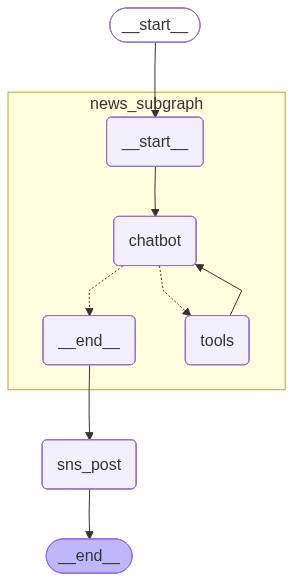

In [15]:
# ---------------------------------------------------
# 서브그래프가 포함된 메인 그래프 정의
# ---------------------------------------------------

# LLM (두 가지 역할에 다른 태그 부여)
news_llm = init_chat_model("openai:gpt-4o-mini").bind_tools(tools).with_config(
    tags=["WANT_TO_STREAM"]  # 뉴스 검색 에이전트 태그
)
sns_llm = init_chat_model("openai:gpt-4o-mini").with_config(
    tags=["WANT_TO_STREAM2"]  # SNS 포스트 생성 에이전트 태그
)


def news_chatbot(state: State) -> dict:
    """뉴스를 검색하고 요약하는 서브그래프용 chatbot."""
    return {"messages": [news_llm.invoke(state["messages"])]}


def create_sns_post(state: State) -> dict:
    """검색된 뉴스를 SNS 포스트 형식으로 변환해요."""
    sns_prompt = """
    이전 대화 내용을 바탕으로 SNS 게시글 형식으로 변환해주세요.
    다음 형식을 따라주세요:
    - 해시태그 포함 (5개 이상)
    - 이모지 사용
    - 간결하고 흥미로운 문체 사용
    - 200자 이내로 작성
    """
    messages = state["messages"] + [("human", sns_prompt)]
    return {"messages": [sns_llm.invoke(messages)]}


# 서브그래프 생성 함수
def create_news_subgraph():
    """뉴스 검색 서브그래프를 생성해요."""
    sub = StateGraph(State)
    sub.add_node("chatbot", news_chatbot)
    sub.add_node("tools", ToolNode(tools=tools))
    sub.add_conditional_edges("chatbot", tools_condition)
    sub.add_edge("tools", "chatbot")
    sub.add_edge(START, "chatbot")
    return sub.compile()


# 메인 그래프 구성
main_builder = StateGraph(State)
main_builder.add_node("news_subgraph", create_news_subgraph())  # 서브그래프를 노드로 추가
main_builder.add_node("sns_post", create_sns_post)
main_builder.add_edge(START, "news_subgraph")
main_builder.add_edge("news_subgraph", "sns_post")
main_builder.add_edge("sns_post", END)

graph_with_subgraph = main_builder.compile()

# 그래프 흐름: START → news_subgraph(서브그래프) → sns_post → END
# news_subgraph: chatbot → tools → chatbot 루프로 뉴스를 검색해요
# sns_post 노드: 검색된 뉴스를 SNS 게시글 형식으로 변환해요
display(Image(graph_with_subgraph.get_graph(xray=True).draw_mermaid_png()))

### 5-1. 서브그래프 내부 생략 (기본 동작)

기본적으로 서브그래프는 하나의 노드처럼 동작해요. 서브그래프 이름이 노드 이름으로 표시되고, 최종 출력만 반환돼요.

> ⚠️ **자주 하는 실수**: `subgraphs=False`(기본)에서는 서브그래프 내부 실행 과정이 보이지 않아요. 서브그래프가 도구를 여러 번 호출해도 최종 결과만 나타나요.

In [16]:
# ---------------------------------------------------
# 서브그래프 내부 생략 (subgraphs=False가 기본값)
# ---------------------------------------------------
inputs = {"messages": [("human", "AI 관련 최신 뉴스를 검색해줘")]}

# ============================================================
# [서브그래프 내부 생략 - 최종 결과만 표시]
# ============================================================

for chunk in graph_with_subgraph.stream(inputs, stream_mode="updates"):
    for node_name, node_chunk in chunk.items():
        print(f"\n[노드: {node_name}]")  # 서브그래프는 news_subgraph 이름으로 표시
        if "messages" in node_chunk:
            node_chunk["messages"][-1].pretty_print()
        else:
            print(node_chunk)


[노드: news_subgraph]
================================== Ai Message ==================================

최근 AI 관련 뉴스는 다음과 같습니다:

1. **현대차그룹, 피지컬 AI 로봇에 125조원 투자 발표** - 지디넷코리아
2. **삼성전자, 갤럭시 S26에 퍼플렉시티 AI 에이전트 기본 탑재** - AI타임스
3. **네이버·카카오, AI 기업으로 전환 가속화** - 한국경제
4. **한국, AI 개발 시 오픈소스 활용률 세계 1위** - 조선일보
5. **LG전자, 가전 AI 에이전트 '스마트홈 AI' 출시** - 연합뉴스

이러한 뉴스들은 AI 기술이 산업 전반에 걸쳐 어떻게 발전하고 있는지를 보여줍니다.

[노드: sns_post]
================================== Ai Message ==================================

🚀 AI 혁명이 가속화되고 있어요! 🤖 현대차, 125조원 투자로 피지컬 AI 로봇 개발 나서고, 삼성은 갤럭시 S26에 AI 에이전트 탑재! 📱 네이버·카카오도 AI 전환을 가속! 한국은 오픈소스 활용 1위! 🇰🇷 LG는 스마트홈 AI 출시! 🏠 #AI #테크뉴스 #현대차 #삼성전자 #스마트홈 #혁신 #오픈소스


### 5-2. 서브그래프 내부 포함 (subgraphs=True)

`subgraphs=True`를 설정하면 서브그래프 내부의 모든 노드 업데이트가 포함돼요.

반환 형태: `(namespace, chunk)` 튜플
- `namespace`: 현재 업데이트가 어느 그래프/서브그래프에서 발생했는지 나타내는 경로 튜플
- `chunk`: 해당 노드의 업데이트

> 🔑 **핵심 개념**: `namespace` 튜플을 파싱하면 업데이트의 출처를 구분할 수 있어요. 빈 튜플 `()`은 메인 그래프, 원소가 있으면 서브그래프예요.

In [17]:
# ---------------------------------------------------
# 서브그래프 내부 포함 (subgraphs=True)
# ---------------------------------------------------
inputs = {"messages": [("human", "AI 관련 최신 뉴스를 검색해줘")]}


def format_namespace(namespace: tuple) -> str:
    """namespace 튜플을 사람이 읽기 좋은 문자열로 변환해요."""
    if len(namespace) == 0:
        return "메인 그래프"  # 빈 튜플 = 메인 그래프
    # namespace의 마지막 원소에서 ':' 앞 부분이 서브그래프 이름
    return namespace[-1].split(":")[0]


# ============================================================
# [서브그래프 내부 포함 - 전체 실행 과정 추적]
# ============================================================

# subgraphs=True: (namespace, chunk) 튜플로 반환
for namespace, chunk in graph_with_subgraph.stream(
    inputs, stream_mode="updates", subgraphs=True
):
    for node_name, node_chunk in chunk.items():
        source = format_namespace(namespace)  # 업데이트 출처
        print(f"\n[{source}] 노드: {node_name}")
        if "messages" in node_chunk:
            node_chunk["messages"][-1].pretty_print()
        else:
            print(node_chunk)


[news_subgraph] 노드: chatbot
================================== Ai Message ==================================
Tool Calls:
  search_news (call_mwjmUzxCm1PD0opLI6kERSfC)
 Call ID: call_mwjmUzxCm1PD0opLI6kERSfC
  Args:
    query: AI

[news_subgraph] 노드: tools
================================= Tool Message =================================
Name: search_news

- 현대차그룹, 피지컬 AI 로봇에 125조원 투자 발표 - 지디넷코리아
- 삼성전자, 갤럭시 S26에 퍼플렉시티 AI 에이전트 기본 탑재 - AI타임스
- 네이버·카카오, AI 기업으로 전환 가속화 - 한국경제
- 한국, AI 개발 시 오픈소스 활용률 세계 1위 - 조선일보
- LG전자, 가전 AI 에이전트 '스마트홈 AI' 출시 - 연합뉴스

[news_subgraph] 노드: chatbot
================================== Ai Message ==================================

다음은 AI 관련 최신 뉴스입니다:

1. **현대차그룹, 피지컬 AI 로봇에 125조원 투자 발표** - 지디넷코리아
2. **삼성전자, 갤럭시 S26에 퍼플렉시티 AI 에이전트 기본 탑재** - AI타임스
3. **네이버·카카오, AI 기업으로 전환 가속화** - 한국경제
4. **한국, AI 개발 시 오픈소스 활용률 세계 1위** - 조선일보
5. **LG전자, 가전 AI 에이전트 '스마트홈 AI' 출시** - 연합뉴스

더 궁금한 내용이 있으면 말씀해 주세요!

[메인 그래프] 노드: news_subgraph
================================== Ai Message 

### 5-3. astream_events()로 서브그래프 내부 토큰 스트리밍

`astream_events()`를 `subgraphs=True`와 함께 사용하면, 서브그래프 내부의 LLM 토큰까지 실시간으로 받을 수 있어요.

| 이벤트 | 설명 |
|---|---|
| `on_chat_model_start` | LLM 호출 시작 |
| `on_chat_model_stream` | LLM 토큰 스트리밍 |
| `on_tool_start` | 도구 호출 시작 |
| `on_tool_end` | 도구 호출 완료 |


In [18]:
# ---------------------------------------------------
# astream_events()로 서브그래프 내부 토큰 스트리밍
# ---------------------------------------------------
inputs = {"messages": [("human", "AI 관련 최신 뉴스를 검색해줘")]}

# ============================================================
# [이벤트 기반 서브그래프 내부 토큰 스트리밍]
# ============================================================

async for event in graph_with_subgraph.astream_events(inputs, version="v2", subgraphs=True):
    kind = event["event"]

    if kind == "on_chat_model_start":
        tags = event.get("tags", [])
        print(f"\n\n[LLM 호출 시작] tags: {tags}")

    elif kind == "on_chat_model_stream":
        data = event["data"]
        if data["chunk"].content:
            print(data["chunk"].content, end="", flush=True)

    elif kind == "on_tool_start":
        data = event["data"]
        print(f"\n\n[도구 호출 시작] input: {data.get('input', {})}")

    elif kind == "on_tool_end":
        data = event["data"]
        output = data.get("output")
        if output:
            print(f"\n[도구 결과]: {str(output.content)[:100]}...")

print()



[LLM 호출 시작] tags: ['seq:step:1', 'WANT_TO_STREAM']


[도구 호출 시작] input: {'query': 'AI'}

[도구 결과]: - 현대차그룹, 피지컬 AI 로봇에 125조원 투자 발표 - 지디넷코리아
- 삼성전자, 갤럭시 S26에 퍼플렉시티 AI 에이전트 기본 탑재 - AI타임스
- 네이버·카카오, AI ...


[LLM 호출 시작] tags: ['seq:step:1', 'WANT_TO_STREAM']
다음은 AI 관련 최신 뉴스입니다:

1. **현대차그룹, 피지컬 AI 로봇에 125조원 투자 발표** - 지디넷코리아
2. **삼성전자, 갤럭시 S26에 퍼플렉시티 AI 에이전트 기본 탑재** - AI타임스
3. **네이버·카카오, AI 기업으로 전환 가속화** - 한국경제
4. **한국, AI 개발 시 오픈소스 활용률 세계 1위** - 조선일보
5. **LG전자, 가전 AI 에이전트 '스마트홈 AI' 출시** - 연합뉴스

더 궁금한 내용이 있으시면 말씀해 주세요!

[LLM 호출 시작] tags: ['seq:step:1', 'WANT_TO_STREAM2']
🚗🤖 현대차가 125조원 투자로 피지컬 AI 로봇 혁신에 나섭니다! 삼성은 갤럭시 S26에 AI 에이전트를 기본 탑재하고, 네이버와 카카오는 AI 기업으로 변신 중! 한국, 오픈소스 활용률 1위🇰🇷✨ #AI #로봇 #오픈소스 #기술혁신 #삼성 #현대 자동차


### 5-4. 특정 태그만 스트리밍

서브그래프 안에 여러 LLM이 있을 때, 원하는 LLM 출력만 선택적으로 스트리밍할 수 있어요.

> 🎯 **강의 포인트**: `WANT_TO_STREAM` 태그가 있는 LLM(뉴스 검색)만 실시간으로 사용자에게 보여주고, `WANT_TO_STREAM2` 태그(SNS 포스트 생성)는 백그라운드에서 처리하는 패턴이에요. 실제 서비스에서 단계적 피드백 UI를 구현할 때 활용해요.

In [19]:
# ---------------------------------------------------
# 특정 태그만 선택해서 스트리밍
# ---------------------------------------------------
inputs = {"messages": [("human", "AI 관련 최신 뉴스를 검색해줘")]}

# 스트리밍하고 싶은 태그만 설정 (WANT_TO_STREAM2는 제외)
ONLY_STREAM_TAGS = ["WANT_TO_STREAM"]

# ============================================================
print(f"[{ONLY_STREAM_TAGS} 태그만 스트리밍]")
# (SNS 포스트 생성 LLM 출력은 표시하지 않아요)
# ============================================================

async for event in graph_with_subgraph.astream_events(inputs, version="v2", subgraphs=True):
    kind = event["event"]
    tags = event.get("tags", [])

    if kind == "on_chat_model_start":
        print(f"\n[LLM 호출 시작] tags: {tags}")

    elif kind == "on_chat_model_stream":
        # ONLY_STREAM_TAGS에 포함된 태그가 있는 경우만 출력해요
        if any(tag in ONLY_STREAM_TAGS for tag in tags):
            data = event["data"]
            if data["chunk"].content:
                print(data["chunk"].content, end="", flush=True)

    elif kind == "on_tool_start":
        data = event["data"]
        print(f"\n[도구 호출] input: {data.get('input', {})}")

    elif kind == "on_tool_end":
        print(f"\n[도구 완료]")

print()

[['WANT_TO_STREAM'] 태그만 스트리밍]

[LLM 호출 시작] tags: ['seq:step:1', 'WANT_TO_STREAM']

[도구 호출] input: {'query': 'AI'}

[도구 완료]

[LLM 호출 시작] tags: ['seq:step:1', 'WANT_TO_STREAM']
최근 AI 관련 뉴스는 다음과 같습니다:

1. **현대차그룹, 피지컬 AI 로봇에 125조원 투자 발표** - 지디넷코리아
2. **삼성전자, 갤럭시 S26에 퍼플렉시티 AI 에이전트 기본 탑재** - AI타임스
3. **네이버·카카오, AI 기업으로 전환 가속화** - 한국경제
4. **한국, AI 개발 시 오픈소스 활용률 세계 1위** - 조선일보
5. **LG전자, 가전 AI 에이전트 '스마트홈 AI' 출시** - 연합뉴스

더 궁금한 점이 있으시면 말씀해 주세요!
[LLM 호출 시작] tags: ['seq:step:1', 'WANT_TO_STREAM2']



## 직접 해보기

아래 TODO 블록을 완성해서 스트리밍 실습을 해보세요!

In [20]:
# ============================================================
# 구현 예시: updates 모드로 노드별 마지막 메시지 출력
# ============================================================

inputs = {"messages": [("human", "반도체 관련 최신 뉴스를 검색해줘")]}

for chunk in graph.stream(inputs, stream_mode="updates"):
    for node_name, node_value in chunk.items():
        print(f"\n[노드: {node_name}]")
        messages = node_value.get("messages", []) if isinstance(node_value, dict) else []
        if messages:
            last_message = messages[-1]
            last_message.pretty_print()
        else:
            print(node_value)



[노드: chatbot]
================================== Ai Message ==================================
Tool Calls:
  search_news (call_KAXpUutjPstK4QyDglbVX8Ct)
 Call ID: call_KAXpUutjPstK4QyDglbVX8Ct
  Args:
    query: 반도체

[노드: tools]
================================= Tool Message =================================
Name: search_news

- 삼성전자 HBM4 양산 일정 앞당겨... NVIDIA 공급 확대 - 매일경제
- SK하이닉스, AI 반도체 수요 급증으로 분기 최대 실적 - 연합뉴스
- 인텔, 차세대 AI 가속기 칩 개발 완료 발표 - 한국경제

[노드: chatbot]
================================== Ai Message ==================================

다음은 반도체 관련 최신 뉴스입니다:

1. **삼성전자 HBM4 양산 일정 앞당겨... NVIDIA 공급 확대** - 매일경제
2. **SK하이닉스, AI 반도체 수요 급증으로 분기 최대 실적** - 연합뉴스
3. **인텔, 차세대 AI 가속기 칩 개발 완료 발표** - 한국경제

이 뉴스들은 최신 반도체 산업 동향을 반영하고 있습니다. 추가 정보가 필요하시면 말씀해 주세요!


## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **`stream_mode="values"`**: 각 노드 실행 후 그래프의 전체 State를 반환해요. `chunk["messages"][-1]`로 새로 추가된 마지막 메시지를 확인할 수 있어요.
- **`stream_mode="updates"`**: 각 노드에서 변경된 부분만 `{노드이름: {변경값}}` 형태로 반환해요. 어떤 노드가 무엇을 했는지 명확히 파악할 수 있어요.
- **`stream_mode="messages"`**: LLM 토큰을 실시간으로 받아요. `(chunk_msg, metadata)` 튜플로 반환되고, `metadata["langgraph_node"]`로 출처 노드를 필터링할 수 있어요.
- **동기 vs 비동기**: `graph.stream()` + `for`, `graph.astream()` + `async for`. 서버 환경에서는 비동기가 성능상 유리해요.
- **태그 기반 필터링**: `.with_config(tags=[...])` + `astream_events()`로 특정 LLM 출력만 선택적으로 스트리밍해요.
- **서브그래프 스트리밍**: `subgraphs=True`로 서브그래프 내부 노드까지 추적해요. `namespace` 튜플로 출처를 구분해요.
- **최종 결과만 추출**: `final_result = None`을 선언하고 스트리밍 루프에서 계속 덮어쓰면, 마지막 청크가 최종 결과가 돼요.

## 다음 노트북 예고

다음 `Part 05의 01-Create-Agent.ipynb`에서는 **`create_agent`를 활용한 에이전트 개발**을 배워요.

지금까지 StateGraph를 직접 구성해서 에이전트를 만들었다면, 이제 LangChain V1의 고수준 API인 `create_agent`를 사용해 더 간결하고 강력한 에이전트를 빠르게 만드는 방법을 배울 거예요. 이 노트북에서 배운 스트리밍 기법은 거기서도 그대로 활용돼요!